In [20]:
import sys

In [21]:
sys.dont_write_bytecode = True

In [22]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle

from GaussianMixtureModel import GaussianMixtureModel

In [23]:
np.random.seed(0)

In [24]:
N = 100000

print(f'Número de Observações: {N}')

Número de Observações: 100000


In [25]:
D = 2

print(f'Dimensão das Observações: {D}')

Dimensão das Observações: 2


In [26]:
M = 5

print(f'Número de Categorias Latentes: {M}')

Número de Categorias Latentes: 5


In [27]:
PI = np.repeat(1/M, repeats = M)

print('Distribuição das Categorias Latentes:\n')

print(PI)

Distribuição das Categorias Latentes:

[0.2 0.2 0.2 0.2 0.2]


In [28]:
ALPHA = np.random.multinomial(n = 1, pvals = PI, size = N).sum(axis = 0)

print('Número de Observações por Categoria Latente:\n')

print(ALPHA)

Número de Observações por Categoria Latente:

[19837 20253 20054 19942 19914]


In [29]:
MU = [

    [-5, -5], [-5, 5],

    [0, 0],

    [5, -5], [5, 5]

]

MU = np.array(MU)

print('Médias por Categoria Latente:\n')

print(MU)

Médias por Categoria Latente:

[[-5 -5]
 [-5  5]
 [ 0  0]
 [ 5 -5]
 [ 5  5]]


In [30]:
SIGMA = [

    [

        [1, -0.75],
        [-0.75, 1]

    ], [

        [1, 0.75],
        [0.75, 1]

    ], [

        [1, 0],
        [0, 1]

    ], [

        [1, 0.75],
        [0.75, 1]

    ], [

        [1, -0.75],
        [-0.75, 1]

    ]
    
]

SIGMA = np.array(SIGMA)

print('Covariâncias por Categoria Latente:\n')

print(SIGMA)

Covariâncias por Categoria Latente:

[[[ 1.   -0.75]
  [-0.75  1.  ]]

 [[ 1.    0.75]
  [ 0.75  1.  ]]

 [[ 1.    0.  ]
  [ 0.    1.  ]]

 [[ 1.    0.75]
  [ 0.75  1.  ]]

 [[ 1.   -0.75]
  [-0.75  1.  ]]]


In [31]:
X, Z = [], []

for m in range(M):

    X.append(

        np.random.multivariate_normal(

            mean = MU[m], cov = SIGMA[m],

            size = ALPHA[m]

        )

    )

    Z.append(

        np.repeat(
            
            m, 
            
            repeats = ALPHA[m]

        )

    )

X, Z = np.vstack(X), np.hstack(Z)

X, Z = shuffle(X, Z)

In [32]:
print('Observações:\n')

print(X)

Observações:

[[ 4.93826566  4.63692346]
 [ 6.73993731 -3.4886457 ]
 [-5.07301256  4.25189746]
 ...
 [ 3.09498405 -6.5881324 ]
 [-5.39349065  4.15371202]
 [ 0.99307498  1.06365695]]


In [33]:
print('Categorias Latentes:\n')

print(Z)

Categorias Latentes:

[4 3 1 ... 3 1 2]


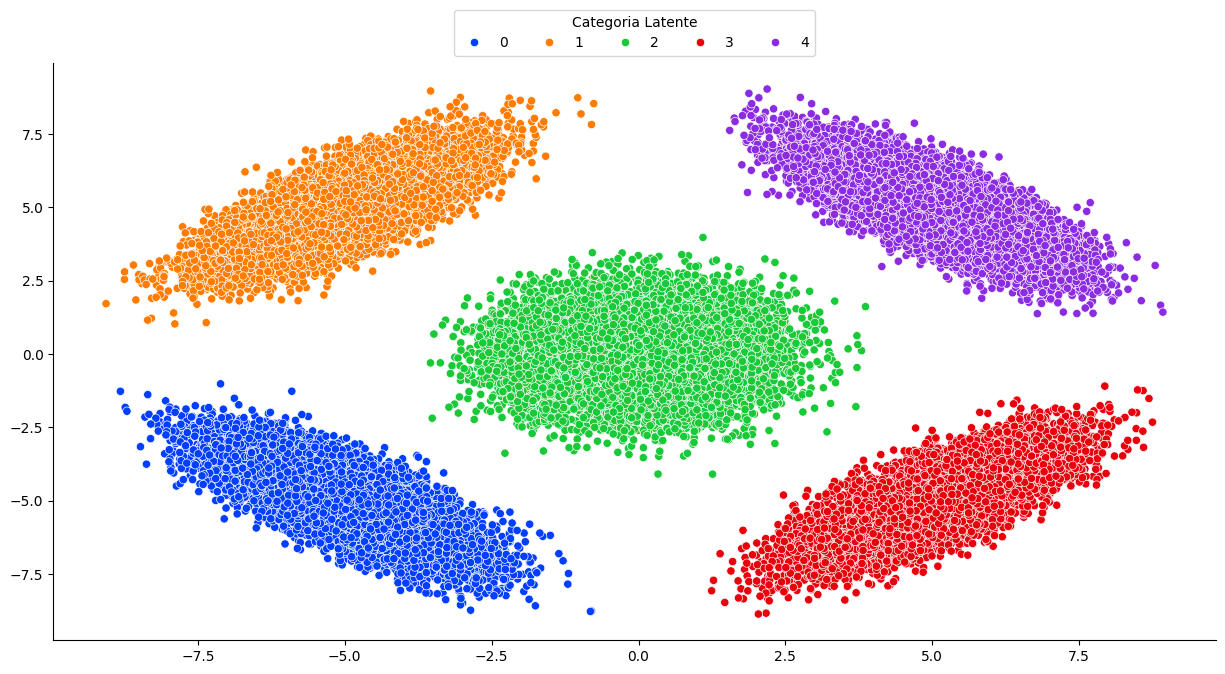

In [34]:
plt.figure(figsize = (15, 7.5))

GRAPHIC = sns.scatterplot(

    x = X[:, 0], y = X[:, 1],

    hue = Z, palette = 'bright'

)

GRAPHIC.spines['right'].set_visible(False)

GRAPHIC.spines['top'].set_visible(False)

sns.move_legend(

    GRAPHIC, 'lower center',

    bbox_to_anchor = (.5, 1), ncol = 5,

    title = 'Categoria Latente'
)

plt.show()

In [35]:
GMM = GaussianMixtureModel(X = X, M = M)

GMM.update_model()

In [36]:
print('Distribuição Estimada das Categorias Latentes:\n')

print(GMM.pi)

Distribuição Estimada das Categorias Latentes:

[0.20054026 0.1983699  0.19941998 0.20252994 0.19913992]


In [37]:
print('Médias Estimadas por Categoria Latente:\n')

print(GMM.mu)

Médias Estimadas por Categoria Latente:

[[ 2.09528926e-04  3.34755878e-04]
 [-5.00453387e+00 -4.99858188e+00]
 [ 4.98784144e+00 -5.00897934e+00]
 [-4.99611867e+00  5.00752149e+00]
 [ 5.00766510e+00  5.00025232e+00]]


In [38]:
print('Covariâncias Estimadas por Categoria Latente:\n')

print(GMM.Sigma)

Covariâncias Estimadas por Categoria Latente:

[[[ 1.00260862  0.00701976]
  [ 0.00701976  1.0163425 ]]

 [[ 1.02112921 -0.76631891]
  [-0.76631891  1.01615764]]

 [[ 0.99838231  0.73984162]
  [ 0.73984162  0.98779717]]

 [[ 0.99919377  0.74365658]
  [ 0.74365658  0.99595859]]

 [[ 1.00664669 -0.75563674]
  [-0.75563674  1.00930139]]]
